# Sistema de 3 ecuaciones diferenciales ordinarias de primer orden

**Alumno: Franco David Barrionuevo** <br>
**Docentes: Carolina Tauro, César Germán Maglione**

**Año:** 2026

In [1]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd
import math
import random

### **a)** Realizá un programa para resolver un sistema de 3 ecuaciones diferenciales ordinarias de primer orden utilizando el método de integración de Euler

In [2]:
# Define Euler Solver in Python
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(x1, x2, x3); f2: EDO g(x1, x2, x3); f3: EDO h(x1, x2, x3)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep 
    '''

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables & lists
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]


    # For loop
    for i in range(steps):

        x1_old = x1
        x2_old = x2
        x3_old = x3

        x1 = x1_old + h*f1(t, x1_old, x2_old, x3_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old, x3_old)
        x3 = x3_old + h*f3(t, x1_old, x2_old, x3_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

### **b)** Utilizá este programa para integrar numéricamente las *ecuaciones de Lorenz*

$\dot{x} = \sigma(y-x)$ <br>
$\dot{y} = rx-y-xz$ <br>
$\dot{z} = xy-bz$

Donde $\sigma = 10$, $r=28$ y $b = 8/3$ son parámetros del problema



In [3]:
# Define parameters values
SIGMA = 10
RHO = 28
BETA = 8/3

# Define df/dt for numerical integration
def dxdt(t, x1,x2, x3):
    # x1: x, x2: y; x3: z
    return SIGMA*(x2-x1)

def dydt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return RHO*x1-x2-x1*x3

def dzdt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return x1*x2-BETA*x3

### c) Comenzando con la condición inicial x(0) = 0, y(0) = 1 y z(0) = 0

- **Graficá la solución x(t), y(t) y z(t).**
- **Realizá gráficos de la trayectoria en los tres planos coordenados (x − z), (x − y) y (z − y).**
- **Graficá la trayectoria en el espacio de la fases tridimensional.**

In [4]:
# Define initial conditions
X10 = 0
X20 = 1
X30 = 0

# Define Euler parameters values
T0 = 0
TF = 50
H = 0.01

# Solve equations using the Euler implementation
t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                   T0, TF, 
                   X10, X20, X30, 
                   H)


**Gráficos de x(t), y(t) y z(t) de la solución de las Ecs. de Lorenz**

Text(0.5, 0.98, 'Gráficos de $x(t)$, $y(t)$ y $z(t)$ vs $t$')

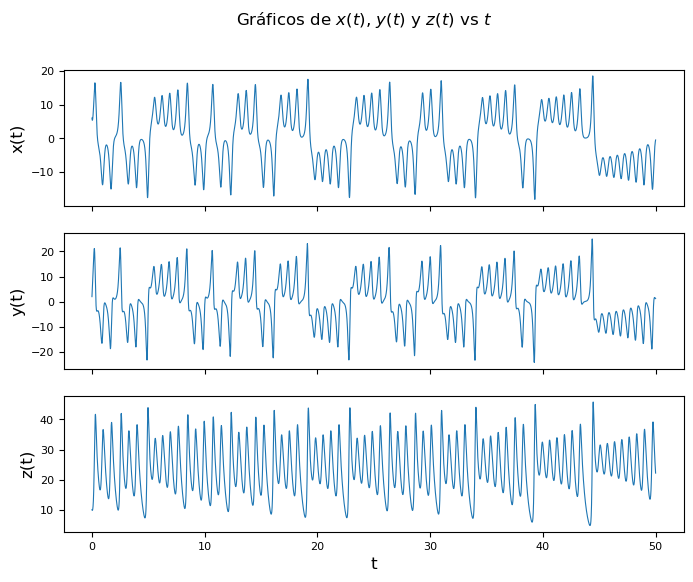

In [147]:
# Plot euler solver results (X1, X2 & X3 vs time phases map)
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex = True)

ax[0].plot(t, x1, lw = 0.8)
ax[1].plot(t, x2, lw = 0.8)
ax[2].plot(t, x3, lw = 0.8)

for i, l in enumerate(['x', 'y', 'z']):
    ax[i].set_ylabel(f'{l}(t)', fontsize = 12)
    ax[i].tick_params(axis='y', labelsize=8) 

ax[2].set_xlabel(f't', fontsize = 12)
ax[2].tick_params(axis='x', labelsize=8)

fig.suptitle('Gráficos de $x(t)$, $y(t)$ y $z(t)$ vs $t$')

**Gráficos de $x$ vs $y$, $x$ vs $z$, e $y$ vs $z$ de la solución de las Ecs. de Lorenz**

Text(0.5, 0.98, 'Gráficos de $x$ vs $y$, $x$ vs $z$, e $y$ vs $z$')

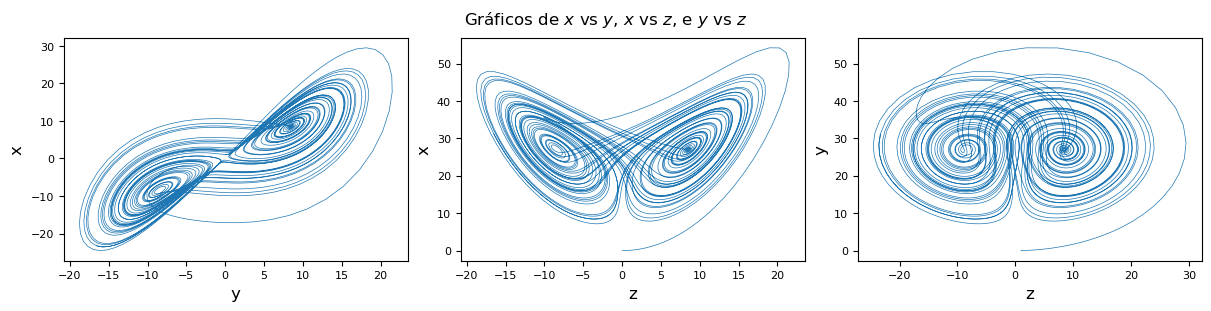

In [ ]:
# Plot projections (x vs y, x vs z & y vs z)
fig, ax = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')

ax[0].plot(x1, x2, lw = 0.5)
ax[1].plot(x1, x3, lw = 0.5)
ax[2].plot(x2, x3, lw = 0.5)

list_axis = [('x', 'y'), ('x', 'z'), ('y', 'z')]

for i, xs in enumerate(list_axis):
    ax[i].set_ylabel(xs[0], fontsize = 12)
    ax[i].tick_params(axis='y', labelsize=8) 

    ax[i].set_xlabel(xs[1], fontsize = 12)
    ax[i].tick_params(axis='x', labelsize=8)

fig.suptitle('Gráficos de $x$ vs $y$, $x$ vs $z$, e $y$ vs $z$')

**Gráfico en tres dimensiones de las soluciones $x$, $y$, y $z$ de las Ecs. de Lorenz**

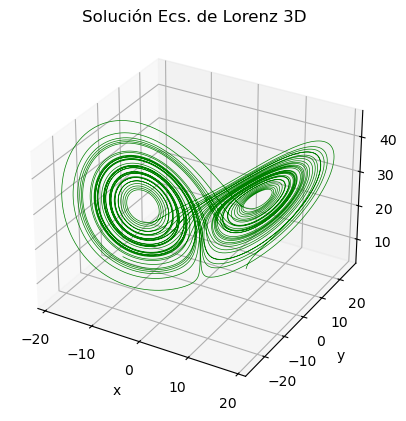

In [140]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot3D(x1, x2, x3, 'green', lw = 0.5)
ax.set_title('Solución Ecs. de Lorenz 3D')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z', labelpad=10)
plt.show()

**Respuesta**

Los gráficos de diagramas de fases de $x(t)$, $y(t)$ y $z(t)$ en función del tiempo (t) para las condiciones iniciales $x_{0}: 0$, $y_{0}: 1$ y $z_{0}: 0$, muestran que las soluciones de las ecuaciones de Lorenz muestran una oscilación irregular alrededor de lo que aparentan ser puntos críticos. Esta oscilación se caracteriza por repetirse a $t \rightarrow \infty$, pero nunca exactamente. 

Por otro lado, al graficar las soluciones de las ecuaciones o trayectorias en términos $x$ vs $y$, $x$ vs $z$, e $y$ vs $z$ se observa la aparición de estructuras que se asemejan a una mariposa. Las trayectorias se caracterizan por realizar un espiral alrededor de un centro, para luego cruzar al lado opuesto y hacer lo mismo. Estas aparentan intersecarse a si mismas, aunque es solo un artefacto de la proyección. Si asi fuere, no cumpliría con el Teorema de unicidad. Esto se verifica al graficarlo en un espacio de tres dimensiones. 


### d) Realizá el diagrama de fases del problema usando al menos 3 condiciones iniciales diferentes. Para cada una de estas trayectorias realizá los gráficos de x(t), y(t) y z(t). Graficá las soluciones con colores diferentes.


Text(0.5, 0.98, 'Gráficos de $x$, $y$, y $z$ vs $t$ para 3 condiciones iniciales diferentes')

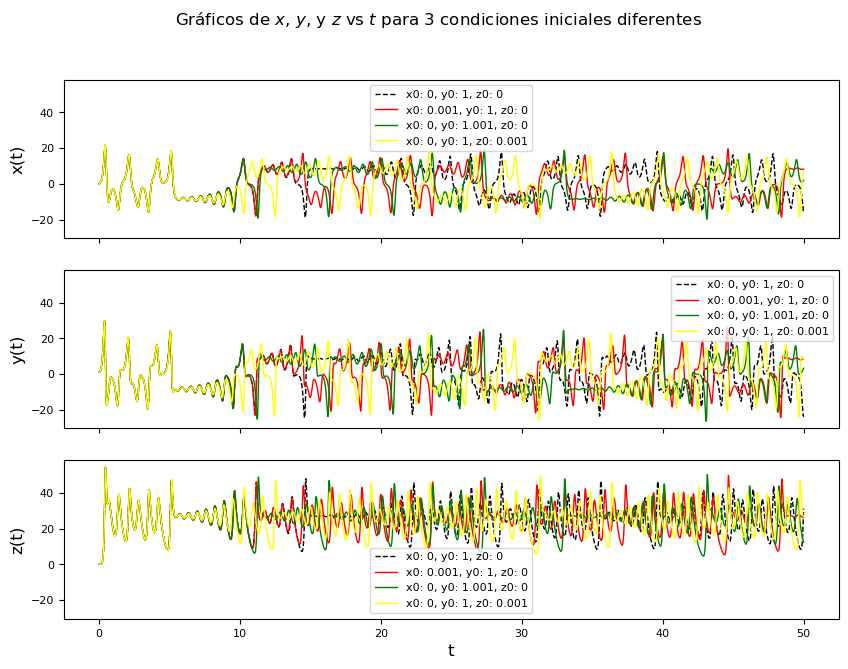

In [ ]:
# Plot euler solver results (X1, X2 & X3 vs time phases diagram)
fig, ax = plt.subplots(3, 1, figsize=(10, 7), sharex = True, sharey = True)

# Plot initial results
t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                    T0, TF, 
                    X10, X20, X30, 
                    H)

ax[0].plot(t, x1, '--', lw = 1, color = 'black', label = f'x0: {X10}, y0: {X20}, z0: {X30}')
ax[1].plot(t, x2, '--', lw = 1, color = 'black', label = f'x0: {X10}, y0: {X20}, z0: {X30}')
ax[2].plot(t, x3, '--', lw = 1, color = 'black', label = f'x0: {X10}, y0: {X20}, z0: {X30}')

# Define a list of colors
list_color = ['red', 'green', 'yellow']

# Define a list of initial conditions
list_iniCond = [(X10+0.001, X20, X30), (X10, X20+0.001, X30), [X10, X20, X30+0.001]]

# For loop to plot results for three random initial conditions
for i, l in enumerate(['x', 'y', 'z']):

    t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                    T0, TF, 
                    list_iniCond[i][0], list_iniCond[i][1], list_iniCond[i][2], 
                    H)

    # Plot results
    ax[0].plot(t, x1, lw = 1, color = list_color[i], 
               label = f'x0: {list_iniCond[i][0]}, y0: {list_iniCond[i][1]}, z0: {list_iniCond[i][2]}')
    ax[1].plot(t, x2, lw = 1, color = list_color[i], 
               label = f'x0: {list_iniCond[i][0]}, y0: {list_iniCond[i][1]}, z0: {list_iniCond[i][2]}')
    ax[2].plot(t, x3, lw = 1, color = list_color[i], 
               label = f'x0: {list_iniCond[i][0]}, y0: {list_iniCond[i][1]}, z0: {list_iniCond[i][2]}')

    # y labels
    ax[i].set_ylabel(f'{l}(t)', fontsize = 12)
    ax[i].tick_params(axis='y', labelsize=8) 
    
    # legnds
    ax[0].legend(fontsize=8)
    ax[1].legend(fontsize=8)
    ax[2].legend(fontsize=8)

# x labels
ax[2].set_xlabel(f't', fontsize = 12)
ax[2].tick_params(axis='x', labelsize=8)

fig.suptitle('Gráficos de $x$, $y$, y $z$ vs $t$ para 3 condiciones iniciales diferentes')

### d) Teniendo en cuenta los resultados de los puntos anteriores... ¿qué le ocurre al sistema cuando se inicializa con condiciones levemente diferentes?

**Respuesta**

Los gráficos de los diagramas de fases para las soluciones de las Ecs. de Lorenz bajo pequeñas alteraciones en las condiciones muestran que las trayectorias en los tres ejes al principio coinciden, aunque rápidamente ($t$~$10$) estas se ven altamente modificadas. De esta manera, a partir del análisis de los gráficos, se conluye que pequeñas alteraciones de las condiciones iniciales conllevan a cambios notables sobre las soluciones/trayectorias de la solución. 

### e)  Elegí una condición inicial y analizá cómo influye la elección del paso de integración.

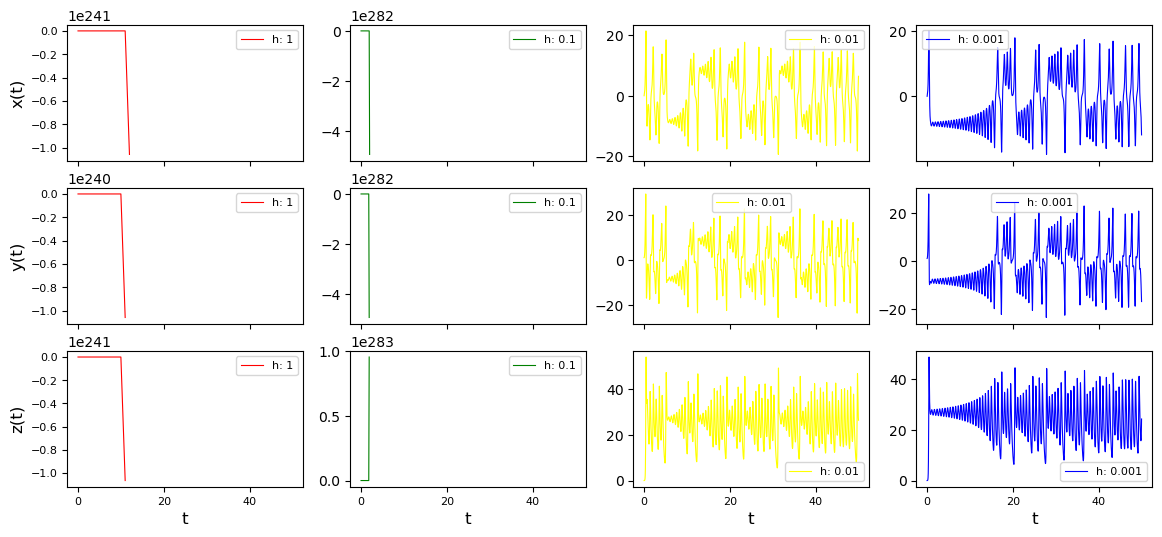

In [ ]:
# Define initial conditions
X10 = 0
X20 = 1
X30 = 0.001

# Define a list of h
list_h = [1, 0.1, 0.01, 0.001]

# Plot euler solver results (X1, X2 & X3 vs time phases map)
fig, ax = plt.subplots(3, 4, figsize=(14, 6), sharex = True)

# Define columns index
j = 0

# Define a list of colors
list_color = ['red', 'green', 'yellow', 'blue']

# For loop for each h case
for i, H in enumerate(list_h):

    t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                    T0, TF, 
                    X10, X20, X30, 
                    H)

    ax[j, i].plot(t, x1, lw = 0.8, color = list_color[i], label = f'h: {H}')
    ax[j+1, i].plot(t, x2, lw = 0.8, color = list_color[i], label = f'h: {H}')
    ax[j+2, i].plot(t, x3, lw = 0.8, color = list_color[i], label = f'h: {H}')

    ax[j, i].legend(fontsize=8)
    ax[j+1, i].legend(fontsize=8)
    ax[j+2, i].legend(fontsize=8)


    # y labels
    for i, l in enumerate(['x', 'y', 'z']):
        ax[i, 0].set_ylabel(f'{l}(t)', fontsize = 12)
        ax[i, 0].tick_params(axis='y', labelsize=8) 

    # x labels
    for i in range(4):
        ax[2, i].set_xlabel(f't', fontsize = 12)
        ax[2, i].tick_params(axis='x', labelsize=8) 

**Respuesta**

Los gráficos de los diagramas de fases para diferentes pasos de integración ($h$) muestran que para los pasos $h= 1$ y $h: 0.01$, la solución de la integración no se condice con los resultados de las trayectorias esperadas. En cambio para los pasos $h= 0.01$ y $h: 0.001$, si se observa el patrón oscilación irregular. Esto se explica por el error ($E$) que se arrastra en cada paso de integración, que es propio del Método de Euler. A pasos $h$ grandes, el error es mayor, mientras que $E \rightarrow 0$ cuando $h \rightarrow 0$. 

### e) Este sistema tiene un atractor extraño o caótico, muchas veces conocido como mariposa de Lorenz, de donde se popularizó el llamado efecto mariposa... te animás a especular el por qué de este nombre?

**Respuesta**

De acuerdo a Strogatz, un atractor se define como un conjunto hacia el que convergen todas las trayectorias que parten de condiciones iniciales cercanas. En el caso de la solución de las Ecs. de Lorenz bajo $\sigma = 10$, $r=28$ y $b = 8/3$, el atractor extraño o caótico al observarlo en tres dimensiones tiene una forma similar a la de las alas de una mariposa. 